In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
import datetime
import utils
import msd_calc
import calc_anisotropy

In [2]:
## Configure parameters
# TODO change output folder settings

# Settings for MSD
MSD_GRAPH_SETTINGS = {
                'hist_n_bins': 45 # Max number of bins to use for MSD histograms (actually calculated as the entire axis range divided by this number). 45 is typically good.
                }

# Settings for Anisotropy
ANISOTROPY_GRAPH_SETTINGS = {
                'rose_n_bins': 16, # Number of bins to use on the roseplots
                            }

# Graph settings
# Color
GRAPH_COLORS = "#5ba567" # Can be set as a single color, a dictionary (condition: color), or a list (in the order of combined_info)
GRAPH_SIZE = 4.94 # inches. generally, graphs are chained together and have a long axis of 1+num_graphs*size and a short axis of 1.75*size.
plt.style.use('../style_prefs.mplstyle')
plt.rcParams['font.size'] = 22 # 22 works well with GRAPH_SIZE 4


In [3]:
# Import data from processing step
combined_tracks, combined_info, general_info = utils.pickle_load()

# Turn user-specified graph color(s) into a list of colors in the same order as combined_info
graph_colors = utils.init_graph_colors(GRAPH_COLORS, combined_info)

fit succeeded for condition wt
Population 1: Weight (A1) = 0.3917, D1 = 0.03461 um^2/s
Population 2: Weight (A2) = 0.6083, D2 = 0.00357 um^2/s
fit succeeded for condition non-neg
Population 1: Weight (A1) = 0.6928, D1 = 0.05221 um^2/s
Population 2: Weight (A2) = 0.3072, D2 = 0.00567 um^2/s
fit succeeded for condition non-pos_lowac
Population 1: Weight (A1) = 0.4374, D1 = 0.03799 um^2/s
Population 2: Weight (A2) = 0.5626, D2 = 0.00280 um^2/s
fit succeeded for condition swap
Population 1: Weight (A1) = 0.4026, D1 = 0.06563 um^2/s
Population 2: Weight (A2) = 0.5974, D2 = 0.00596 um^2/s


/tmp/ipykernel_20555/1865906422.py:55: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Noto Sans Math.
  plt.savefig("op/cdf_fig.svg")
/home/dl/EG/venv/patwd/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Noto Sans Math.
  fig.canvas.print_figure(bytes_io, **kw)


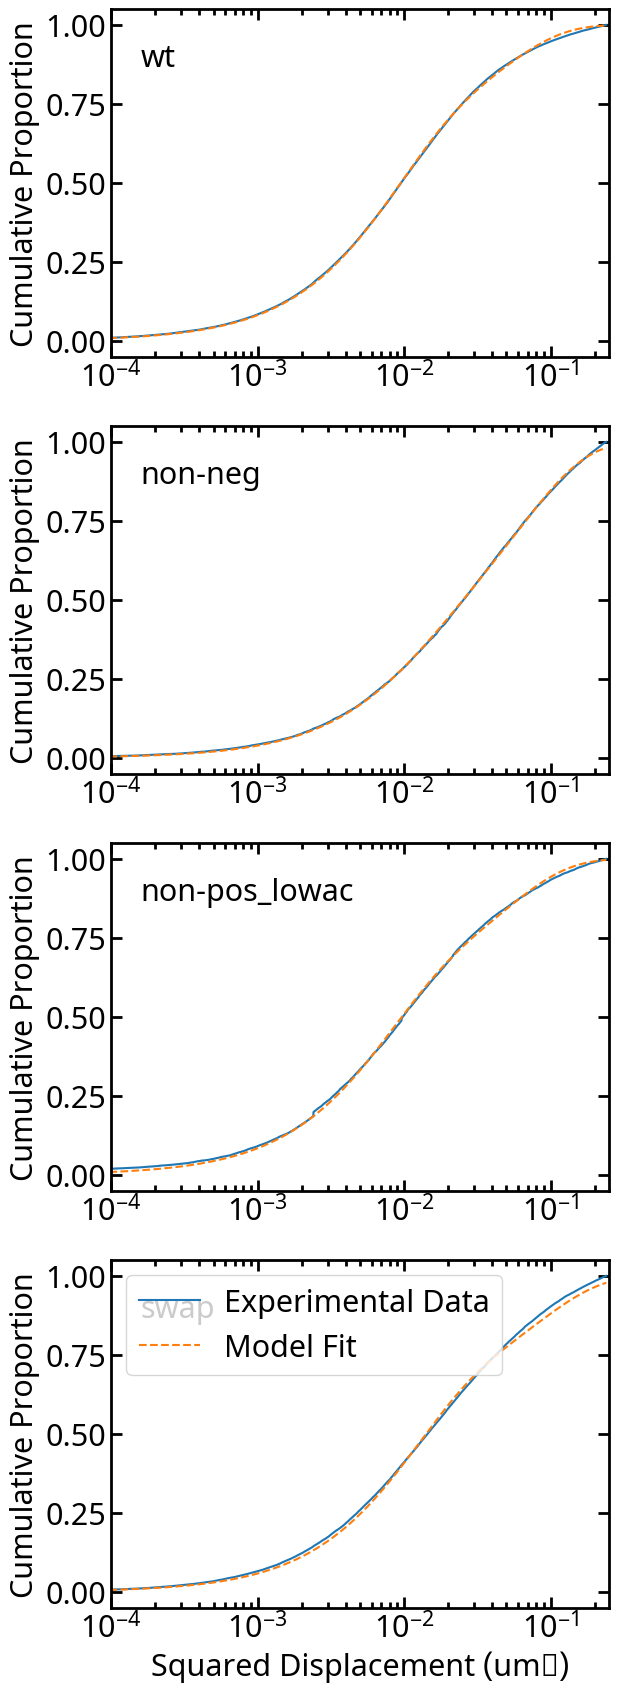

In [4]:
import math
from scipy.optimize import minimize

fig, ax = plt.subplots(nrows=len(combined_info), figsize=(GRAPH_SIZE*1.3,1+GRAPH_SIZE*len(combined_info)))
ax = [ax] if len(combined_info) == 1 else ax

def eqn_2(D):
    time_term = .35-(.15/3)
    localization_term = 2*(.03**2+.03**2)
    return 2*2*D*time_term+localization_term

def eqn_1(prop_1, r2, D1, D2):
    ri12 = eqn_2(D1)
    ri22 = eqn_2(D2)
    main_section = prop_1*np.exp(-r2/ri12)+(1-prop_1)*np.exp(-r2/ri22)
    return 1-main_section

def sq_difference_between_P(params, r2):
    prop_1, D1, D2 = params
    # r2 must be sorted
    Pfit = eqn_1(prop_1, r2, D1, D2)
    n = len(r2)
    Pdata = np.arange(1, n + 1) / n
    # print(Pfit)
    # print(Pdata)
    return np.sum((Pdata - Pfit) ** 2)

for r in range(len(combined_info)):
    condition = combined_info.index[r]
    condition_tracks = combined_tracks[combined_tracks['condition'] == condition]
    raw_r2 = condition_tracks['squared_displacement'].sum()
    raw_r2 = [x for x in raw_r2 if not math.isnan(x)]
    sorted_r2 = np.array(sorted(raw_r2))
    results = minimize(sq_difference_between_P, x0=[0.4, 0.1, 0.01], args=(sorted_r2,), bounds=((0, 1), (0, None), (0, None)))

    if results.success:
        A1_fit, D1_fit, D2_fit = results.x
        print(f"fit succeeded for condition {condition}")
        print(f"Population 1: Weight (A1) = {A1_fit:.4f}, D1 = {D1_fit:.5f} um^2/s")
        print(f"Population 2: Weight (A2) = {1-A1_fit:.4f}, D2 = {D2_fit:.5f} um^2/s")
    else:
        print(f"Fit failed for condition {condition}: {results.message}")

    # Optional: Plot the fitted curve over the experimental data to check goodness-of-fit
    n = len(sorted_r2)
    Pdata = np.arange(1, n + 1) / n
    ax[r].semilogx(sorted_r2, Pdata, label='Experimental Data')
    fit_cdf = eqn_1(A1_fit, sorted_r2, D1_fit, D2_fit)
    ax[r].semilogx(sorted_r2, fit_cdf, '--', label='Model Fit')
    ax[r].set_xlim(10**-4, .25)
    ax[r].text(x=10**-3.8, y=0.87, s=f"{condition}")
    ax[r].set_ylabel("Cumulative Proportion")
plt.legend()
plt.xlabel("Squared Displacement (um²)")
plt.savefig("op/cdf_fig.svg")
plt.show()

/tmp/ipykernel_20555/3095052018.py:49: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Noto Sans Math.
  plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_msd-histograms_t-int-{general_info['MSD_SETTINGS']['t_int']}_min-frames-{general_info['MSD_SETTINGS']['min_frames']}_max-gap-{general_info['MSD_SETTINGS']['max_gap']}.svg")


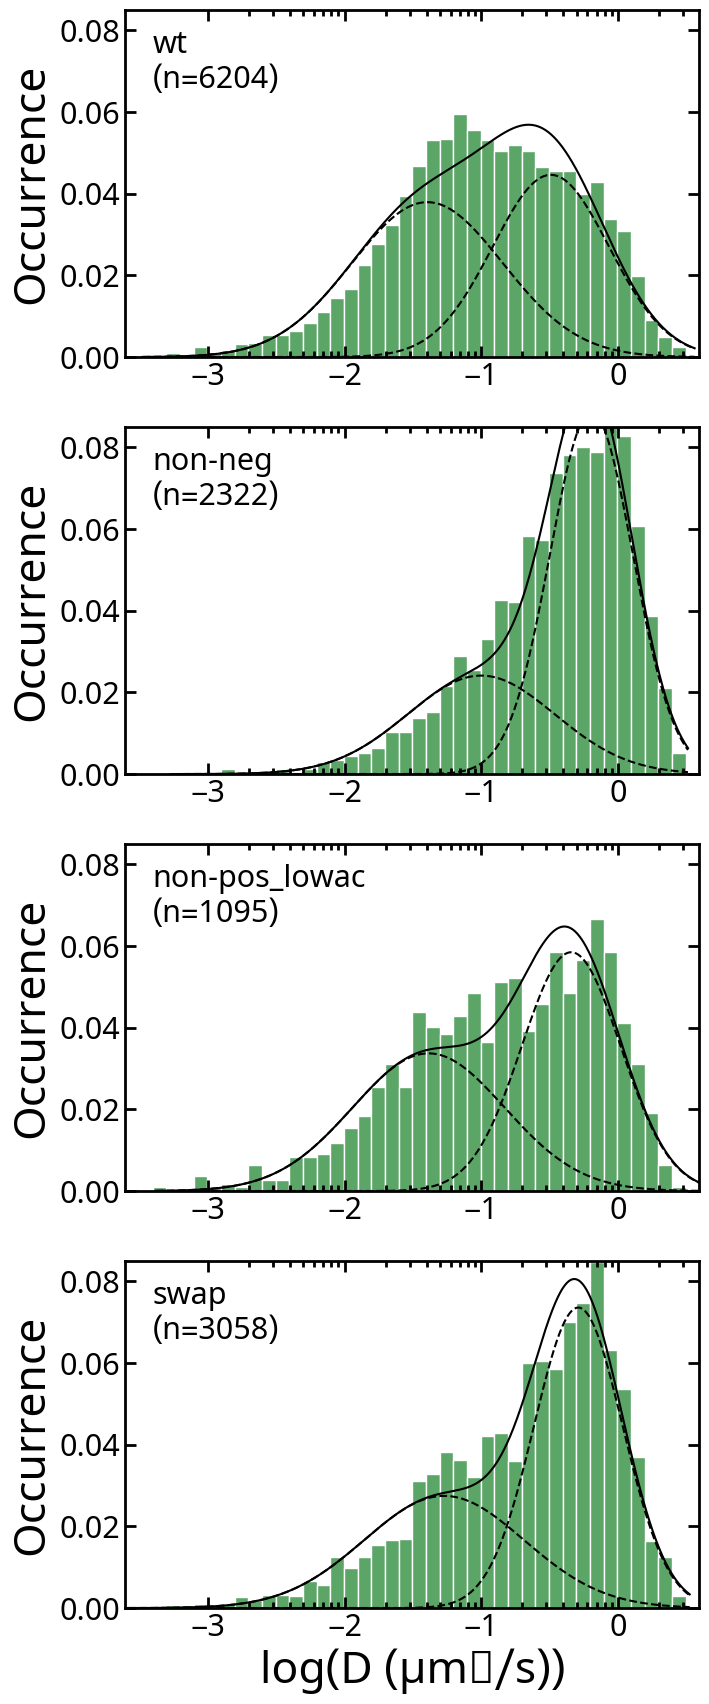

In [5]:
## This cell: Graph GMMs/D-values
# Initialize axes for graph
fig, ax = plt.subplots(nrows=len(combined_info), figsize=(GRAPH_SIZE*1.5,1+GRAPH_SIZE*len(combined_info)))
ax = [ax] if len(combined_info) == 1 else ax

# Iterate through each condition
for r in range(len(combined_info)):
    condition = combined_info.index[r]
    # log_condition_MSDs stores the log of MSD values matching the current condition
    log_condition_MSDs = msd_calc.calc_log_condition_MSDs(combined_tracks, condition)

    # Graph setup
    ax[r].set_xlim(general_info['min_msd']+.3, general_info['max_msd'])
    ax[r].set_ylim(0, .085)
    bins = np.arange(general_info['min_msd'], general_info['max_msd'], (general_info['max_msd'] - general_info['min_msd']) / MSD_GRAPH_SETTINGS['hist_n_bins'])

    # Graph the histogram of D-values.
    ax[r].hist(log_condition_MSDs, bins=bins, density=False, weights=np.full((len(log_condition_MSDs), 1), 1/len(log_condition_MSDs)), edgecolor="white", color=graph_colors[r])
    
    # Now calculate and plot functions representing the Gaussians
    x_plot = np.linspace(log_condition_MSDs.min(), log_condition_MSDs.max(), 1000)
    combined_function = np.zeros_like(x_plot)
    for i in range(combined_info.at[condition, "gmm_n_comps"]):
        std_dev = np.sqrt(combined_info.at[condition, "gmm_variances"][i])
        pdf = norm.pdf(x_plot, loc=combined_info.at[condition, "gmm_means"][i], scale=std_dev)
        # Scale the PDF by its weight in the mixture
        # This represents the contribution of this component to the overall mixture PDF
        ax[r].plot(x_plot, combined_info.at[condition, "gmm_weights"][i] * pdf / 10, linestyle='--', color="black")
        combined_function += combined_info.at[condition, "gmm_weights"][i] * pdf
        # plot a dotted line indicating the mean
        # ax[r].plot([combined_info.at[condition, "gmm_means"][i], combined_info.at[condition, "gmm_means"][i]], [0, .085], color="red", linestyle=":")
    # ax[r].plot([np.mean(log_condition_MSDs), np.mean(log_condition_MSDs)], [0, .085], color="blue", linestyle=":")
    ax[r].plot(x_plot, combined_function / 10, color="black")


    # Place some labels and annotations that show up on each sub-graph
    ax[r].text(x=general_info['min_msd']+.5, y=.08, s=f"{condition}\n(n={str(len(log_condition_MSDs))})", verticalalignment='top')
    # ax[r].text(x=general_info['min_msd']+.5, y=.08, s=f"$\\mathsf{{log(D_{{avg}})}}$ {np.mean(log_condition_MSDs):.3f}", verticalalignment='top', fontsize=32)
    minor_ticks = []
    for i in range(-3, 1):
        minor_ticks.extend(np.log10(np.arange(2, 10)) + i)

    ax[r].xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
    ax[r].set_ylabel("Occurrence", fontsize=32)
    

# Labels that only show up once
plt.xlabel("log(D (μm²/s))", fontsize=32)
plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_msd-histograms_t-int-{general_info['MSD_SETTINGS']['t_int']}_min-frames-{general_info['MSD_SETTINGS']['min_frames']}_max-gap-{general_info['MSD_SETTINGS']['max_gap']}.svg")
plt.show()

In [6]:
combined_info

,gmm_n_comps,gmm_means,gmm_err_NOTLOG,gmm_variances,gmm_weights,gmm_weight_err,gmm_criterium,gmm_optimization_data,fold_anisotropy,fold_anisotropy_err,anisotropy_by_displacement,intermediate_disp_fold_anisotropy,anisotropy_err,p-val_against_reference
condition,,,,,,,,,,,,,,
wt,2,"[-1.3941041300368457, -0.48990044093891627]","[[0.038213561509146766, 0.043538955919304526],...","[0.30542425809063845, 0.18083662256144606]","[0.5249029613309084, 0.47509703866909164]","[[0.5051289570845153, 0.5527177048550466], [0....",12536.088691,None,1.546453,"[1.4663128582133382, 1.608512190061097]",displacement anisotropy anisotropy_err 0 ...,1.644122,0.106596,1.0
non-neg,2,"[-0.9999812654318465, -0.19332720056259955]","[[0.0864976275384572, 0.1205079462709138], [0....","[0.29113437138688975, 0.09227460673949109]","[0.3257860273786078, 0.6742139726213922]","[[0.30077425913446304, 0.3831993460154496], [0...",3392.923428,None,1.134086,"[1.055233755137856, 1.2019908677564897]",displacement anisotropy anisotropy_err 0 ...,1.170937,0.12038,0.0
non-pos_lowac,2,"[-1.3845879789506923, -0.3410646868852966]","[[0.035447402220652104, 0.061859434434102196],...","[0.3098317166940941, 0.1309782180264924]","[0.47000083514147556, 0.5299991648585244]","[[0.43069581079137853, 0.6257236335291958], [0...",2218.119424,None,1.185393,"[1.0208314938551486, 1.337354760028077]",displacement anisotropy anisotropy_err 0 ...,1.406689,0.224431,0.12
swap,2,"[-1.2712592208968887, -0.28907090232602256]","[[0.04798883372916783, 0.059626769640828435], ...","[0.3422083723344859, 0.10521258139586731]","[0.4023549674813073, 0.5976450325186928]","[[0.36917061697506526, 0.43251941482244016], [...",5593.767379,None,1.265348,"[1.1905582909349526, 1.3375454213715583]",displacement anisotropy anisotropy_err 0 ...,1.431257,0.118063,0.03


15497
8857
3320
12416


/tmp/ipykernel_20555/903520192.py:24: UserWarning: Glyph 176 (\N{DEGREE SIGN}) missing from font(s) Noto Sans Math.
  plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_anisotropy_ring_min-D-{general_info['ANISOTROPY_SETTINGS']['min_D']}_max-D-{general_info['ANISOTROPY_SETTINGS']['max_D']}.svg")
/home/dl/EG/venv/patwd/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 176 (\N{DEGREE SIGN}) missing from font(s) Noto Sans Math.
  fig.canvas.print_figure(bytes_io, **kw)


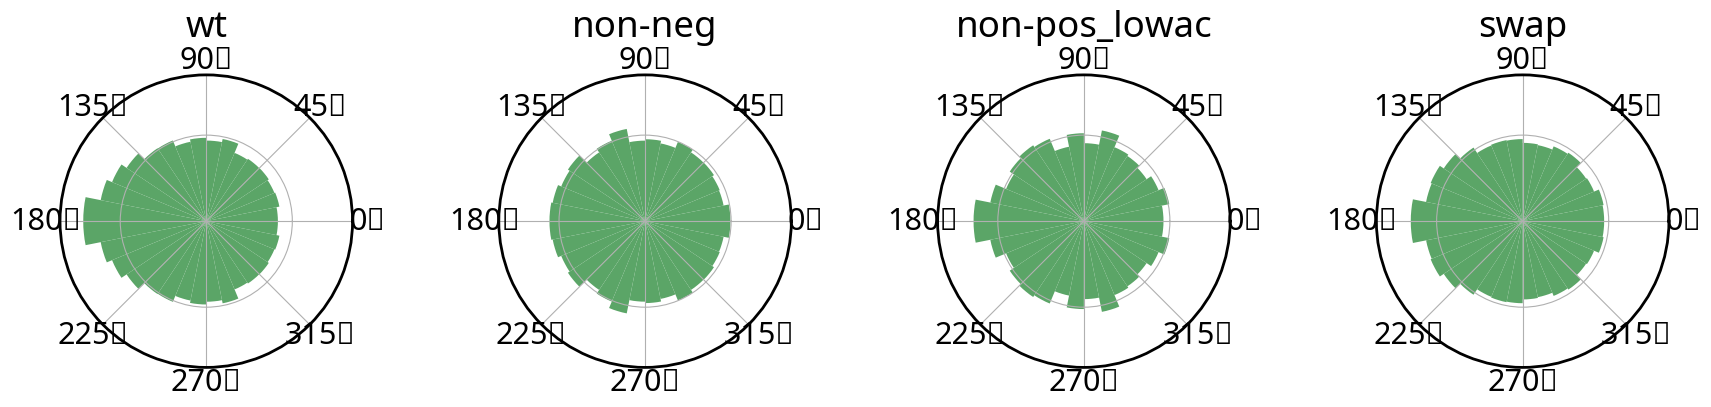

In [7]:
## Plot anisotropy as ring plots
fig, ax = plt.subplots(ncols=len(combined_info), subplot_kw={'projection': 'polar'}, figsize=(1+GRAPH_SIZE*len(combined_info),GRAPH_SIZE*1.75))
ax = [ax] if len(combined_info) == 1 else ax

# For each condition
for r in range(len(combined_info)):
    #condition_angles = list(filter(lambda i: not pd.isna(i), condition_angles))
    condition = combined_info.index[r]
    # Get angles for this condition (via a utility function)
    condition_angles = calc_anisotropy.get_condition_angles(combined_tracks, condition, general_info['ANISOTROPY_SETTINGS'])
    ax[r].set_yticklabels([])
    # TODO fix this manual specification (1.7)
    ax[r].set_ylim(0, 1.7/ANISOTROPY_GRAPH_SETTINGS['rose_n_bins'])
    # Set the circle to mark even distribution (Julie's idea)
    ax[r].set_yticks([1/ANISOTROPY_GRAPH_SETTINGS['rose_n_bins']])
    condition_angles = np.radians(condition_angles)
    print(len(condition_angles))
    ax[r].hist(condition_angles, bins=ANISOTROPY_GRAPH_SETTINGS['rose_n_bins'], color=graph_colors[r], density=False, weights=np.full(len(condition_angles), 1/len(condition_angles)))
    # Now the mirror image version
    ax[r].hist(-condition_angles, bins=ANISOTROPY_GRAPH_SETTINGS['rose_n_bins'], color=graph_colors[r], density=False, weights=np.full(len(condition_angles), 1/len(condition_angles)))
    ax[r].set_title(condition)
# Otherwise they overlap
plt.subplots_adjust(wspace=.5)
plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_anisotropy_ring_min-D-{general_info['ANISOTROPY_SETTINGS']['min_D']}_max-D-{general_info['ANISOTROPY_SETTINGS']['max_D']}.svg")
plt.show()

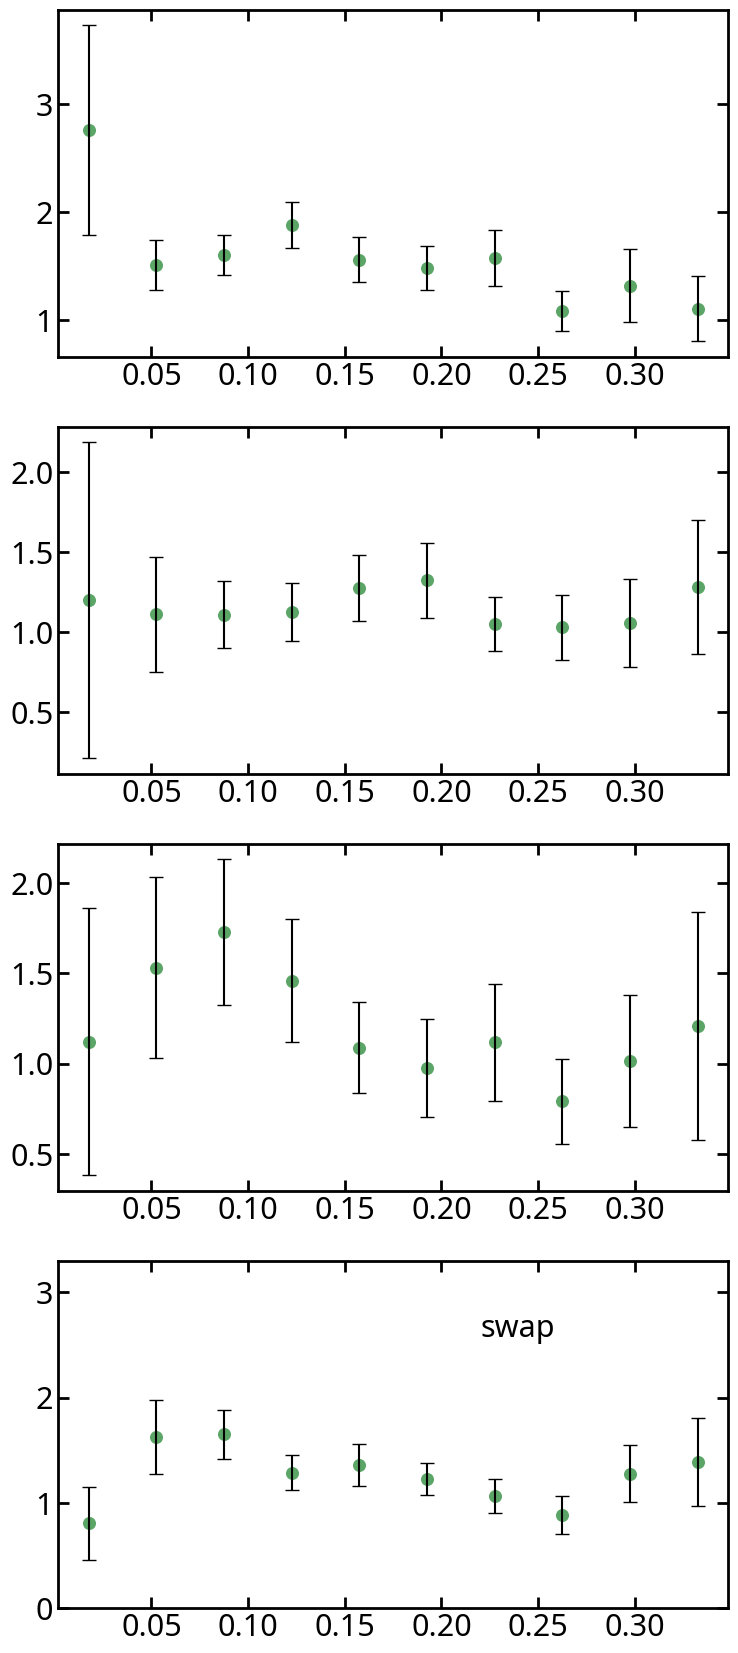

In [8]:
fig, ax = plt.subplots(nrows=len(combined_info), figsize=(GRAPH_SIZE*1.75,1+GRAPH_SIZE*len(combined_info)))
ax = [ax] if len(combined_info) == 1 else ax

for r in range(len(combined_info)):
    condition = combined_info.index[r]
    data_for_graph = combined_info.at[condition, 'anisotropy_by_displacement']

    
    # Add things to the graph
    ax[r].scatter(x=data_for_graph['displacement'], y=data_for_graph['anisotropy'], s=70, color=graph_colors[r])
    ax[r].errorbar(x=data_for_graph['displacement'], 
                   y=data_for_graph['anisotropy'], 
                   yerr=data_for_graph['anisotropy_err'], 
                   linestyle='', 
                   color='black',
                   capsize = 5)
ax[r].set_ylim(0, 3.3)
ax[r].text(x=.22, y=2.8, s=f"{condition}", verticalalignment='top')
plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_step-resolved-anisotropy_min-D-{general_info['ANISOTROPY_SETTINGS']['min_D']}_max-D-{general_info['ANISOTROPY_SETTINGS']['max_D']}.svg")
plt.show()

/tmp/ipykernel_20555/2078698528.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


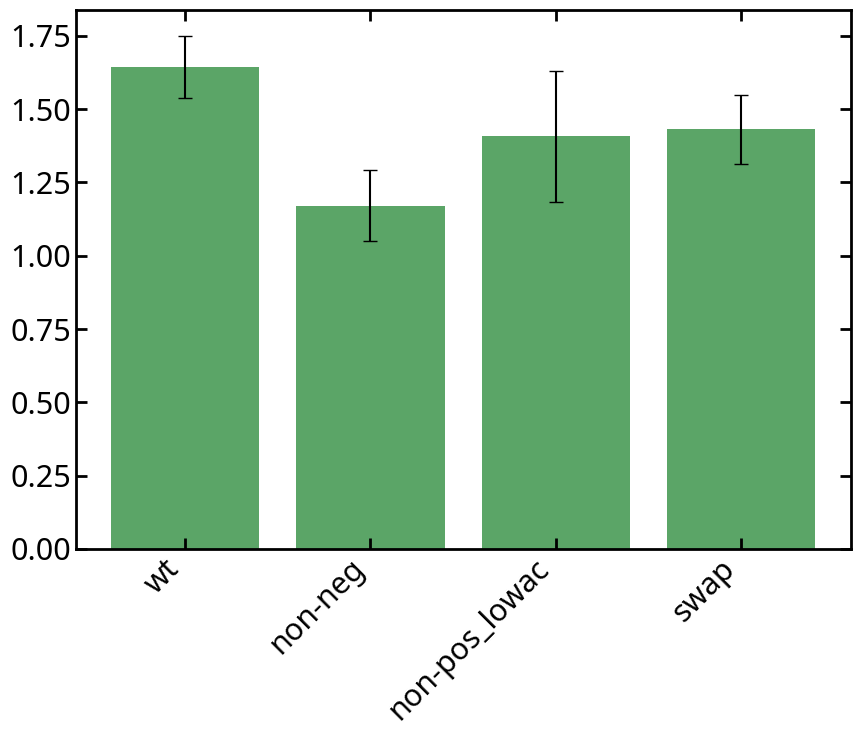

In [9]:
# Setup
fig, ax = plt.subplots(figsize=(10,7))

ax.bar(combined_info.index, combined_info['intermediate_disp_fold_anisotropy'], color=graph_colors)
ax.errorbar(x=combined_info.index, y=combined_info['intermediate_disp_fold_anisotropy'], yerr=combined_info['anisotropy_err'], color="black", fmt="none", capsize=5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.savefig(f"op/{datetime.datetime.now().strftime('%Y%m%d')}_anisotropy-bar-intermediate_disp-range-{general_info['ANISOTROPY_SETTINGS']['min_mean_displacement']}-{general_info['ANISOTROPY_SETTINGS']['max_mean_displacement']}um.svg")
plt.show()